# Data Exploration

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
import contextily as ctx
import branca.colormap as c

import pyproj
from skgstat import Variogram


sns.set_style("whitegrid")

In [24]:
df_buoy = pd.read_csv('output/north_sea_cphl_cleaned.csv')
df = pd.read_csv('data/sentinel_points_combined.csv')

In [25]:
# Check missing values
missing = df.isna().sum().sort_values(ascending=False)
# print(missing.head(30))

# Check valid rows
print("Rows with satellite data:", (df["valid_pixel_count"] > 0).sum())

# Filter out rows with no valid satellite pixels
df = df[df["valid_pixel_count"] > 0]

Rows with satellite data: 6867


In [26]:
df["STATN"].nunique()

120

In [27]:
df.describe()["year"]

count    6867.000000
mean     2020.043542
std         2.361145
min      2016.000000
25%      2018.000000
50%      2020.000000
75%      2022.000000
max      2024.000000
Name: year, dtype: float64

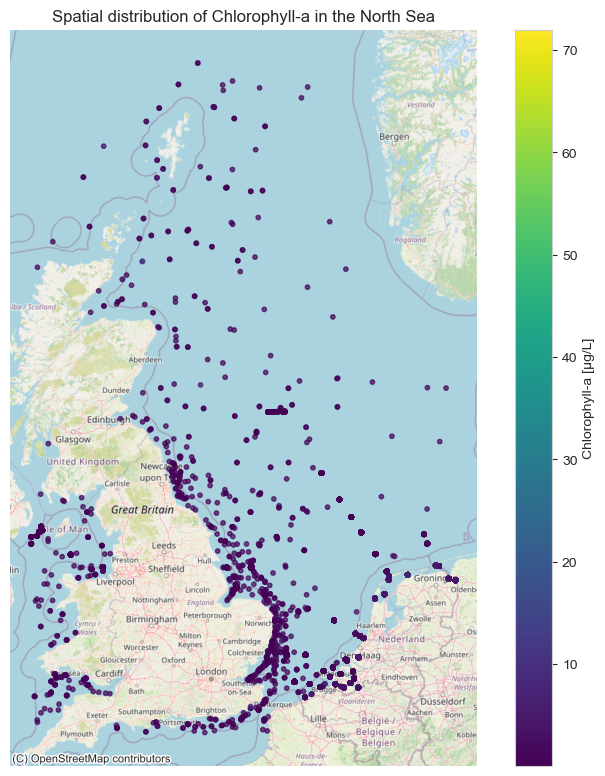

In [28]:
# Remove rows with missing coordinates or chlorophyll values
df_map = df.dropna(subset=["Latitude", "Longitude", "Value"]).copy()

# Convert to GeoDataFrame (WGS84)
gdf = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map["Longitude"], df_map["Latitude"]),
    crs="EPSG:4326"
)

# Reproject to Web Mercator for basemap compatibility
gdf = gdf.to_crs(epsg=3857)

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot chlorophyll points
gdf.plot(
    ax=ax,
    column="Value",
    cmap="viridis",
    markersize=10,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': "Chlorophyll-a [µg/L]"}
)

# Add OpenStreetMap basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
ax.set_title("Spatial distribution of Chlorophyll-a in the North Sea")
fig.tight_layout()

# fig.savefig("chl_map.pdf", bbox_inches="tight")
plt.show()

In [29]:
# Used for QGIS

# Round coordinates if needed (optional, to merge "almost same" points)
df["lat_round"] = df["Latitude"].round(4)
df["lon_round"] = df["Longitude"].round(4)

# Take mean per location
df_avg = (
    df.groupby(["lat_round", "lon_round"], as_index=False)
      .agg({"Value": "mean"})
)

df_avg["log_value"] = np.log10(df_avg["Value"])

# Convert back to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_avg,
    geometry=gpd.points_from_xy(df_avg["lon_round"], df_avg["lat_round"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

gdf.to_file("chlorophyll_points.gpkg", driver="GPKG")

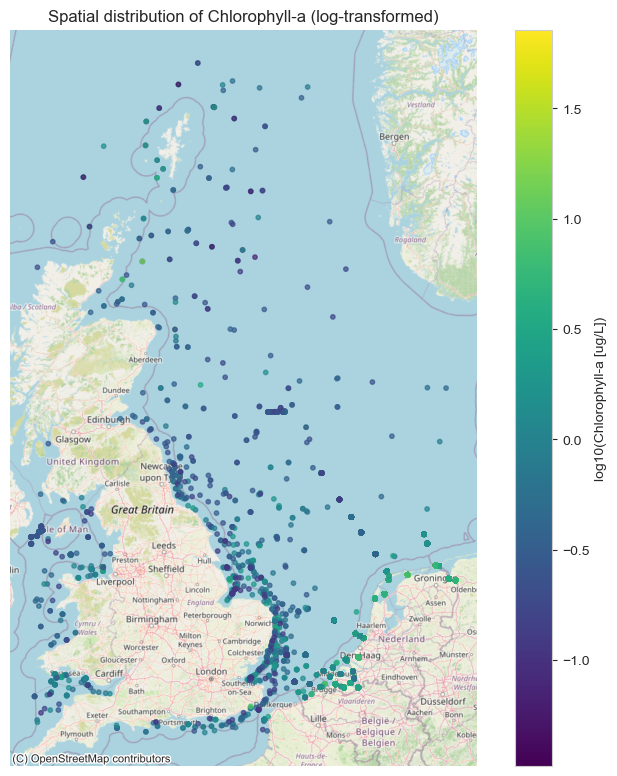

In [30]:
# Remove rows with missing coordinates or chlorophyll values
df_map = df.dropna(subset=["Latitude", "Longitude", "Value"]).copy()

# Log-transform of chlorophyll
df_map["log_chl"] = np.log10(df_map["Value"])

# Convert to GeoDataFrame (WGS84)
gdf = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map["Longitude"], df_map["Latitude"]),
    crs="EPSG:4326"
)

# Reproject to Web Mercator for basemap compatibility
gdf = gdf.to_crs(epsg=3857)

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot chlorophyll points
gdf.plot(
    ax=ax,
    column="log_chl",
    cmap="viridis",
    markersize=10,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': "log10(Chlorophyll-a [ug/L])"}
)

# Add OpenStreetMap basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
ax.set_title("Spatial distribution of Chlorophyll-a (log-transformed)")
fig.tight_layout()

# fig.savefig("chl_map.pdf", bbox_inches="tight")
plt.show()

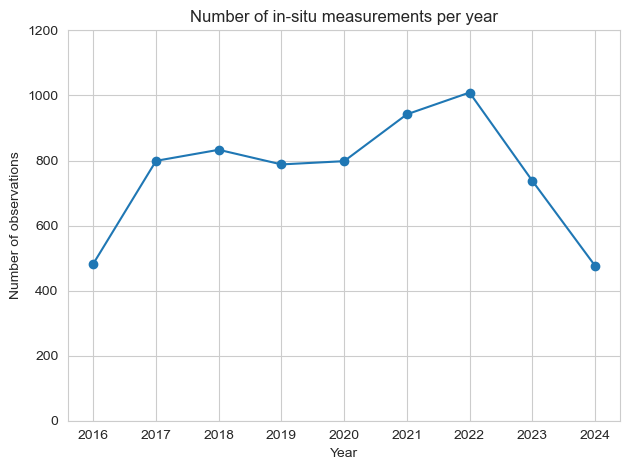

In [31]:
counts_per_year = df.groupby("year").size()

counts_per_year.plot(marker="o")
plt.xlabel("Year")
plt.ylabel("Number of observations")
plt.title("Number of in-situ measurements per year")
plt.ylim(0, 1200)
plt.tight_layout()
plt.show()

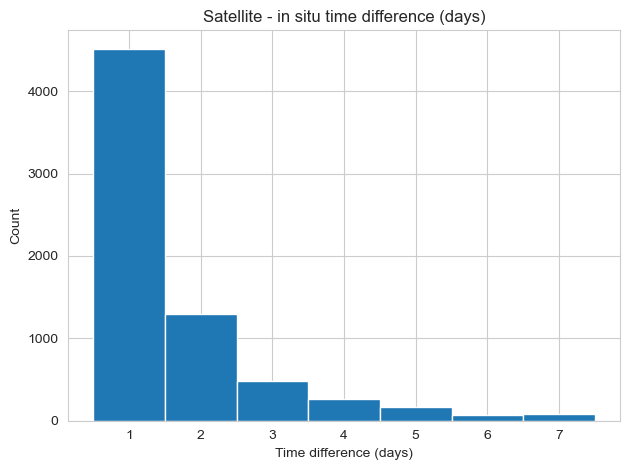

In [32]:
df["time_diff_days"] = df["sat_time_diff_hours"] / 24

fig, ax = plt.subplots()

ax.hist(df["time_diff_days"].dropna(), bins=7)
ax.set_xlabel("Time difference (days)")
ax.set_ylabel("Count")
ax.set_title("Satellite - in situ time difference (days)")
fig.tight_layout()

fig.savefig("output/Time_difference.pdf")
plt.show()

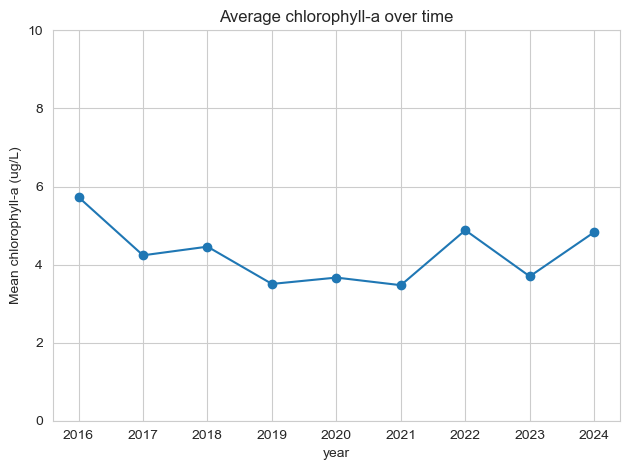

In [33]:
chl_year = df.groupby("year")["Value"].mean()

chl_year.plot(marker="o")
plt.ylabel("Mean chlorophyll-a (ug/L)")
plt.title("Average chlorophyll-a over time")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

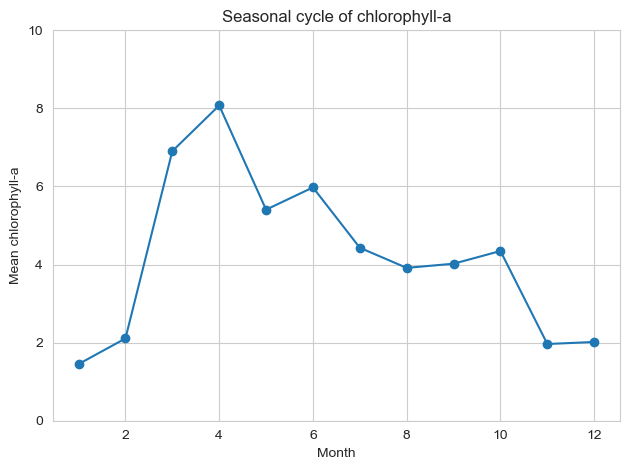

In [34]:
chl_month = df.groupby("month")["Value"].mean()

fig, ax = plt.subplots()

ax.plot(chl_month.index, chl_month.values, marker="o")

ax.set_xlabel("Month")
ax.set_ylabel("Mean chlorophyll-a")
ax.set_title("Seasonal cycle of chlorophyll-a")
ax.set_ylim(0, 10)

fig.tight_layout()
fig.savefig("output/Chl_seasonal_cycle.pdf", bbox_inches="tight")

plt.show()

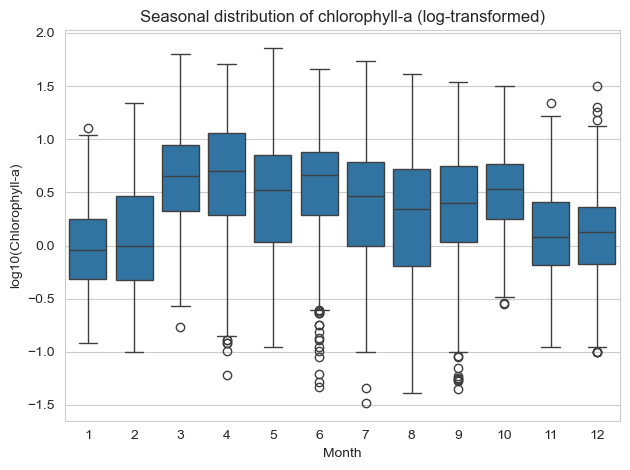

In [35]:
fig, ax = plt.subplots()

# sns.boxplot(data=df, x="month", y="Value", ax=ax)
sns.boxplot(data=df, x="month", y=np.log10(df["Value"]), ax=ax)

ax.set_xlabel("Month")
ax.set_ylabel("log10(Chlorophyll-a)")
ax.set_title("Seasonal distribution of chlorophyll-a (log-transformed)")

fig.tight_layout()
fig.savefig("output/Chl_boxplot_per_month.pdf", bbox_inches="tight")

plt.show()

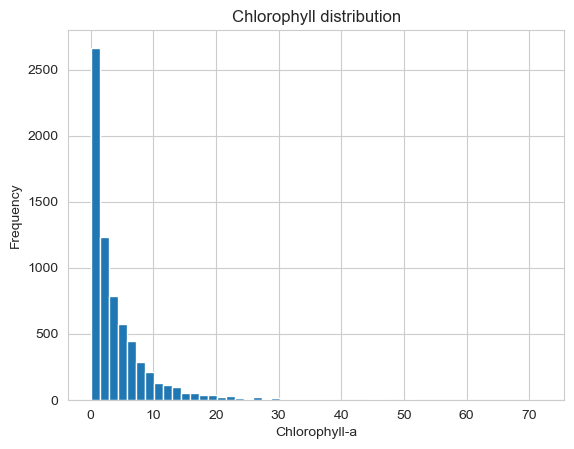

In [36]:
ig, ax = plt.subplots()

ax.hist(df["Value"].dropna(), bins=50)

ax.set_title("Chlorophyll distribution")
ax.set_xlabel("Chlorophyll-a")
ax.set_ylabel("Frequency")

fig.tight_layout()
fig.savefig("output/Chl_histogram.pdf", bbox_inches="tight")

plt.show()

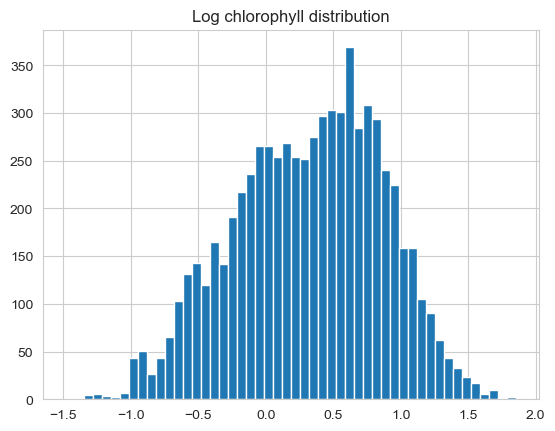

In [37]:
# log-scale
plt.hist(np.log10(df["Value"].dropna()), bins=50)
plt.title("Log chlorophyll distribution")
plt.show()



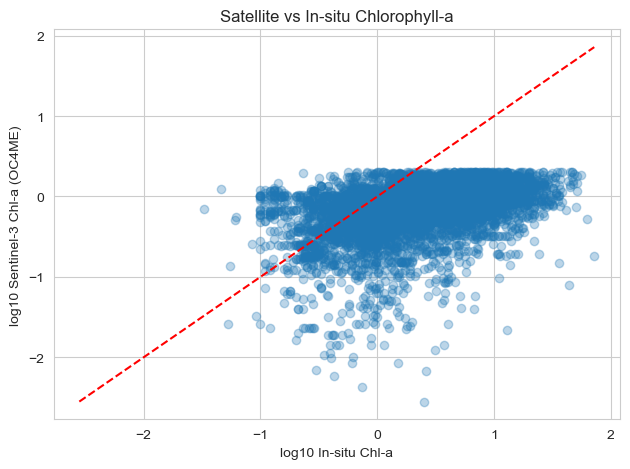

In [38]:

df_clean = df

# Log transform
df_clean["log_insitu"] = np.log10(df_clean["Value"])
df_clean["log_sat"] = np.log10(df_clean["s3_CHL_OC4ME_mean"])

# Create figure
fig, ax = plt.subplots()

ax.scatter(df_clean["log_insitu"], df_clean["log_sat"], alpha=0.3)

lims = [
    min(df_clean["log_insitu"].min(), df_clean["log_sat"].min()),
    max(df_clean["log_insitu"].max(), df_clean["log_sat"].max()),
]

ax.plot(lims, lims, 'r--')

ax.set_xlabel("log10 In-situ Chl-a")
ax.set_ylabel("log10 Sentinel-3 Chl-a (OC4ME)")
ax.set_title("Satellite vs In-situ Chlorophyll-a")

fig.tight_layout()

# Save as high-quality PDF (vector format)
fig.savefig("output/Chl_scatter.pdf")

plt.show()

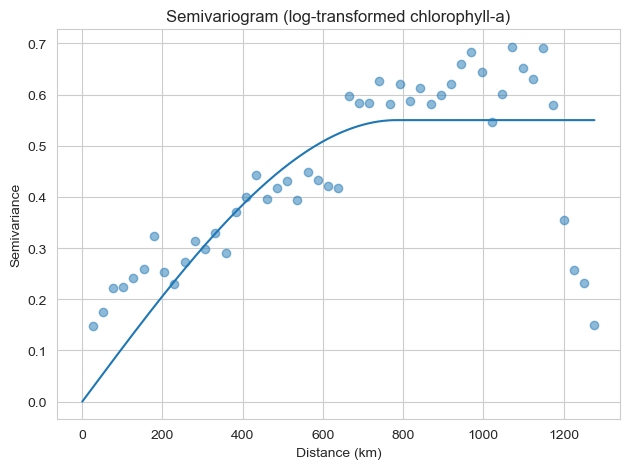

In [39]:
fig, ax = plt.subplots()

proj = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:28992", always_xy=True)
x, y = proj.transform(df_clean["Longitude"].values,
                      df_clean["Latitude"].values)
coords = np.column_stack([x, y])

values = np.log10(df["Value"]) 

V = Variogram(coords, values, n_lags=50)

# experimental points
ax.scatter(V.bins/1000, V.experimental, alpha=0.5)

# fitted model line
x = np.linspace(0, V.bins.max(), 200)
ax.plot(x/1000, V.fitted_model(x))

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Semivariance")
ax.set_title("Semivariogram (log-transformed chlorophyll-a)")

fig.tight_layout()
fig.savefig("output/semivariogram.pdf", bbox_inches="tight")

plt.show()

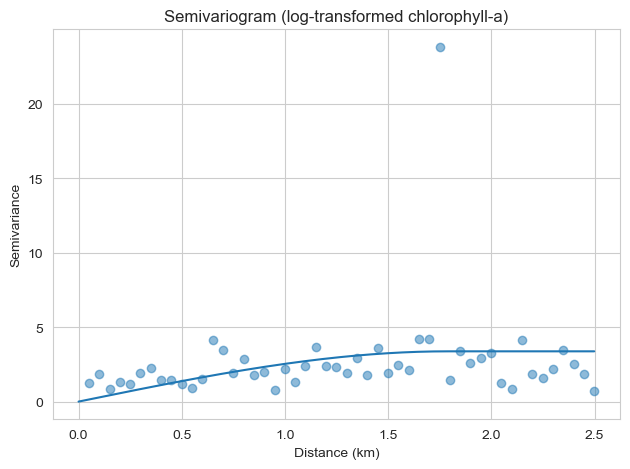

In [40]:
fig, ax = plt.subplots()

proj = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:28992", always_xy=True)
x, y = proj.transform(df_clean["Longitude"].values,
                      df_clean["Latitude"].values)
coords = np.column_stack([x, y])

values = df["Value"]
# values = np.log10(df["Value"]) 

V = Variogram(coords, values, n_lags=50, maxlag=2500)

# experimental points
ax.scatter(V.bins/1000, V.experimental, alpha=0.5)

# fitted model line
x = np.linspace(0, V.bins.max(), 200)
ax.plot(x/1000, V.fitted_model(x))

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Semivariance")
ax.set_title("Semivariogram (log-transformed chlorophyll-a)")

fig.tight_layout()
fig.savefig("output/semivariogram_zoomed_in.pdf", bbox_inches="tight")

plt.show()

In [41]:
print(df[["DATE", "sat_interval_from", "sat_interval_to", "sat_interval_mid_utc"]].iloc[1])

DATE                                   2016-04-19
sat_interval_from       2016-04-26T00:00:00+00:00
sat_interval_to         2016-04-27T00:00:00+00:00
sat_interval_mid_utc    2016-04-26T12:00:00+00:00
Name: 35, dtype: object


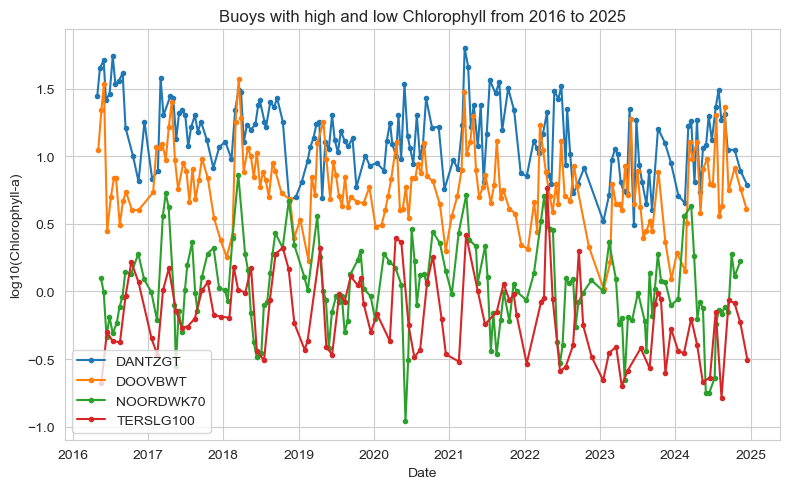

In [42]:
# Ensure DATE is datetime and drop missing values
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
df = df.dropna(subset=['DATE', 'Value'])

# Log-transform chlorophyll
df['Value_log'] = np.log10(df['Value'])

# ID buoys with highest and lowest average chlorophyll
high_avg_buoy = "DANTZGT"
high_avg_buoy2 = "DOOVBWT"
low_avg_buoy = "NOORDWK70"
low_avg_buoy2 = "TERSLG100"

def average_per_date(df_buoy):
    # group by DATE and take median of Value_log if multiple measurements exist
    return df_buoy.groupby('DATE', as_index=False)['Value_log'].mean().sort_values('DATE')


df_high = average_per_date(df[df['STATN'] == high_avg_buoy])
df_high2 = average_per_date(df[df['STATN'] == high_avg_buoy2])
df_low = average_per_date(df[df['STATN'] == low_avg_buoy])
df_low2 = average_per_date(df[df['STATN'] == low_avg_buoy2])

# Plot both
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(df_high['DATE'], df_high['Value_log'], marker='.', linestyle='-', label=f'{high_avg_buoy}')
ax.plot(df_high2['DATE'], df_high2['Value_log'], marker='.', linestyle='-', label=f'{high_avg_buoy2}')
ax.plot(df_low['DATE'], df_low['Value_log'], marker='.', linestyle='-', label=f'{low_avg_buoy}')
ax.plot(df_low2['DATE'], df_low2['Value_log'], marker='.', linestyle='-', label=f'{low_avg_buoy2}')

ax.set_xlabel("Date")
ax.set_ylabel("log10(Chlorophyll-a)")
ax.set_title("Buoys with high and low Chlorophyll from 2016 to 2025")
ax.legend()
fig.tight_layout()

# Save figure as PDF
fig.savefig("output/high_low_avg_buoys.pdf", bbox_inches="tight")
plt.show()

In [43]:
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
df = df.dropna(subset=['DATE', 'Value'])

summary_df = df.groupby('STATN').agg(
    avg_chlorophyll = ('Value', 'mean'),         # average chlorophyll
    unique_dates    = ('DATE', 'nunique')        # number of unique measurement dates
).reset_index()


summary_df = summary_df.sort_values('avg_chlorophyll', ascending=False)
summary_df.head(3)

,STATN,avg_chlorophyll,unique_dates
14,DANTZGT,16.524224,161
102,W01,8.511667,12
59,MOW1,7.907154,51


In [44]:
# ensure all are datetime 
try:
    df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce').dt.tz_localize('UTC')
    df['sat_interval_from'] = pd.to_datetime(df['sat_interval_from'], errors='coerce')
    df['sat_interval_to'] = pd.to_datetime(df['sat_interval_to'], errors='coerce')
    df['sat_interval_mid_utc'] = pd.to_datetime(df['sat_interval_mid_utc'], errors='coerce')
except Exception as e:
    # You cant rerun this cell
    print("Error converting to datetime:", e)